In [1]:
import os
import sys
sys.path.append('../src')

import pandas as pd

import numpy as np
from scipy.ndimage import center_of_mass
from scipy.optimize import curve_fit
from scipy.special import erf
from scipy.signal import lombscargle
from scipy.fft import fft2, ifftshift, fftshift, ifft2
from scipy.interpolate import RegularGridInterpolator, interp1d
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import r2_score, mean_squared_error
import cv2
import math
import matplotlib.pyplot as plt

from pathlib import Path
import swifter

from data_mining.image.common import *


# 配置swifter参数以优化性能
swifter.set_defaults(
    npartitions=os.cpu_count(),  # 分区数量，根据CPU核心数调整
    dask_threshold=100,  # 数据量阈值，超过此数量使用dask
    disable_cache=False,  # 启用缓存
    progress_bar=True  # 显示进度条
)

root_dir = Path('../data/002')
assert root_dir.exists(), f"数据目录不存在: {root_dir}"

def process_time_columns(df):
    """
    处理DataFrame中的时间相关列
    
    Args:
        df (pd.DataFrame): 要处理的DataFrame
    
    Returns:
        pd.DataFrame: 处理后的DataFrame
    """
    df = df.copy()
    # 添加time列
    df['time'] = df['path'].apply(lambda x: x.stem)
    # 提取括号内信息
    df['info'] = df['time'].str.extract(r'[（\(]([^）\)]*)[）\)]')[0]
    # 转换时间格式
    df['time'] = pd.to_datetime(
        df['time'].str.split('(').str[0].str.replace('：', ':', regex=False),
        format='%Y%m%d %H:%M:%S.%f'
    )
    return df

# 选择数据目录

In [2]:
# load power meter data
power_dir = root_dir / Path('digitaloptical4Floor/功率计数据')
power_file = power_dir.glob('*.TXT', case_sensitive=False).__next__()

power_data = pd.read_csv(power_file, sep='\t', encoding='gbk', header=None)
power_data.columns = ['time', 'power']

load_time = power_file.stem[:17]
load_info = power_file.stem[18:-1]

saved_info = f'{load_time}({load_info})'
saved_info

'20251219 09：29：37(20%平顶31)'

# 功率数据

In [ ]:
power_data['time'] = pd.to_datetime(power_data['time'], format='%Y-%m-%d-%H：%M：%S.%f')
power_data['delta_time'] = (power_data['time'] - power_data['time'].iloc[0]).dt.total_seconds().astype(float)

t_data = power_data['delta_time'].to_numpy()
P_data = power_data['power'].to_numpy()

## 拟合erf/sigmod

对于**带上升沿和下降沿的功率曲线（如激光脉冲、光开关响应等）**，且**上升/下降时间未知**，推荐使用 **“平滑阶跃函数”组合模型**。这类函数既能描述平台区（恒定功率），又能用可调参数刻画上升/下降沿的**形状和时间位置**。

----

**双误差函数模型（Double Error Function）**

$$
P(t) = P_0 + \frac{A}{2} \left[ 
\operatorname{erf}\left( \frac{t - t_1}{\sigma_1} \right) 
- \operatorname{erf}\left( \frac{t - t_2}{\sigma_2} \right) 
\right]
$$

🔍 参数含义：
| 参数 | 物理意义 |
|------|----------|
| $P_0$ | 基线功率（脉冲前/后的背景） |
| $A$ | 脉冲幅度（平台高度） |
| $t_1$ | **上升沿中心时间**（50% 上升点附近） |
| $\sigma_1$ | **上升沿陡峭度**（越小越陡，$\tau_{\text{rise}} \propto \sigma_1$） |
| $t_2$ | **下降沿中心时间**（50% 下降点附近） |
| $\sigma_2$ | **下降沿陡峭度** |

----

**双 Sigmoid 脉冲模型**

$$
P(t) = P_0 + A \left[ 
\frac{1}{1 + e^{-k_1 (t - t_1)}} 
- \frac{1}{1 + e^{-k_2 (t - t_2)}}
\right]
$$

🔍 参数说明：
| 参数 | 含义 |
|------|------|
| $P_0$ | 基线功率（脉冲前/后的背景值） |
| $A$ | 脉冲平台高度（幅度） |
| $t_1$ | 上升沿中心时间（Sigmoid 中点，≈50% 上升点） |
| $k_1$ | 上升沿陡峭度（越大越陡，$k_1 > 0$） |
| $t_2$ | 下降沿中心时间（Sigmoid 中点，≈50% 下降点） |
| $k_2$ | 下降沿陡峭度（越大越陡，$k_2 > 0$） |

In [ ]:
power_data['time'] = pd.to_datetime(power_data['time'], format='%Y-%m-%d-%H：%M：%S.%f')
power_data['delta_time'] = (power_data['time'] - power_data['time'].iloc[0]).dt.total_seconds().astype(float)

def double_sigmoid(t, P0, A1, k, t1, k1, t2, k2):
    """
    双 Sigmoid 脉冲模型

    $$
    P(t) = P_0 + A \left[ 
    \frac{1}{1 + e^{-k_1 (t - t_1)}} 
    - \frac{1}{1 + e^{-k_2 (t - t_2)}}
    \right]
    $$

    #### 🔍 参数说明：
    | 参数 | 含义 |
    |------|------|
    | $P_0$ | 基线功率（脉冲前/后的背景值） |
    | $A$ | 脉冲平台高度（幅度） |
    | $t_1$ | 上升沿中心时间（Sigmoid 中点，≈50% 上升点） |
    | $k_1$ | 上升沿陡峭度（越大越陡，$k_1 > 0$） |
    | $t_2$ | 下降沿中心时间（Sigmoid 中点，≈50% 下降点） |
    | $k_2$ | 下降沿陡峭度（越大越陡，$k_2 > 0$） |
    """
    rise = 1 / (1 + np.exp(-k1 * (t - t1)))
    fall = 1 / (1 + np.exp(-k2 * (t - t2)))
    return P0 + A1 * (rise - k * fall)

def estimate_initial_params_sigmoid(t, P):
    """
    从数据粗略估计双 Sigmoid 的初始参数
    """
    P_min, P_max = np.min(P), np.max(P)
    P0_est = P_min
    A_est = P_max - P_min
    
    # 找 50% 幅度对应的时间（近似 t1, t2）
    mid_level = P0_est + 0.5 * A_est
    above_mid = np.where(P >= mid_level)[0]
    
    if len(above_mid) == 0:
        raise ValueError("无法估计脉冲位置")
    
    t1_est = t[above_mid[0]]   # 第一个超过50%的点 → 上升中点
    t2_est = t[above_mid[-1]]  # 最后一个超过50%的点 → 下降中点
    
    # 估计 k：假设上升/下降跨越 ~5个时间单位
    dt = np.mean(np.diff(t))
    k1_est = k2_est = 2.0 / dt  # 初始陡峭度（经验值）
    
    return [P0_est, A_est, 1, t1_est, k1_est, t2_est, k2_est]

def bounds_sigmoid(t, P):
    avg_t = np.diff(t).mean()
    bounds_low = [
        np.min(P) - 0.5,      # P0
        0.1,              # A > 0
        1,
        np.min(t),            # t1
        0.1,              # k1 > 0
        np.min(t),            # t2
        0.1               # k2 > 0
    ]
    bounds_high = [
        np.max(P),            # P0
        np.max(P) - np.min(P),  # A
        2,
        np.max(t),            # t1
        10.0 / avg_t,    # k1 上限（非常陡）
        np.max(t),            # t2
        10.0 / avg_t     # k2 上限
    ]
    return bounds_low, bounds_high

# 3. 计算 10%-90% 上升/下降时间（更工程化）
p0 = estimate_initial_params_sigmoid(t_data, P_data)

popt, pcov = curve_fit(
    double_sigmoid, t_data, P_data,
    p0=p0,
    bounds=bounds_sigmoid(t_data, P_data),
    maxfev=5000
)
P0, A1, k, t1, k1, t2, k2 = popt

t_fine = np.linspace(np.min(t_data), np.max(t_data), 10000)
P_fine = double_sigmoid(t_fine, *popt)

def find_time_for_fraction(frac):
    target = P0 + frac * A1
    # 在拟合曲线上插值找时间
    idx = np.argmin(np.abs(P_fine - target))
    return t_fine[idx]

t_rise_10 = find_time_for_fraction(0.1)
t_rise_90 = find_time_for_fraction(0.9)
rise_time = t_rise_90 - t_rise_10

# 注意：下降沿是从高到低，所以要找下降段的90%和10%
# 更准确做法：在 t > (t1+t2)/2 区域找
t_mid = (t1 + t2) / 2
mask_fall = t_fine > t_mid
t_fall_90 = t_fine[mask_fall][np.argmin(np.abs(P_fine[mask_fall] - (P0 + 0.9*A1*k)))]
t_fall_10 = t_fine[mask_fall][np.argmin(np.abs(P_fine[mask_fall] - (P0 + 0.1*A1*k)))]
fall_time = t_fall_10 - t_fall_90  # 应为正数

plt.figure(figsize=(10, 5))
plt.scatter(t_data, P_data, s=15, alpha=0.6, label='Measured Data')
plt.plot(t_fine, P_fine, 'r-', linewidth=2, label='Fit Data')
plt.axhline(P0 + 0.1*A1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(P0 + 0.9*A1, color='gray', linestyle='--', alpha=0.5)
plt.title(
    f'R2 score: {r2_score(P_data, double_sigmoid(t_data, *popt)):.3f}, Rise Time: {rise_time:.3f}, Fall Time: {fall_time:.3f}')
plt.xlabel('Time')
plt.ylabel('Power')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 插值计算上下降时间

In [ ]:
def find_arise_dura(p, t):
    inc_p = p
    inc_t = t
    p_func = interp1d(inc_p, inc_t)
    p_10 = np.max(p) * 0.1
    t_10 = p_func(p_10)
    p_90 = np.max(p) * 0.9
    t_90 = p_func(p_90)

    return t_90 - t_10

max_id = np.argmax(P_data)
arise_time = find_arise_dura(P_data[:max_id], t_data[:max_id])
decent_time = find_arise_dura(P_data[max_id::-1], t_data[max_id::-1])

print(f'{arise_time=:.4f}, {decent_time=:.4f}')

# 图像分析

## 载入与过滤

In [3]:
# load image data
ref_axis_dir = root_dir / Path(f'digitaloptical4Floor/光轴image/{load_time}(全子束弱光平顶)')

axis_beam_dir = root_dir / Path(f'digitaloptical4Floor/光轴image/{saved_info}')
pupil_beam_dir = root_dir / Path(f'digitaloptical4Floor/光瞳image/{saved_info}')

ref_to_weak_light = False
if ref_axis_img_path := list(ref_axis_dir.glob('*.TIFF')):
    ref_axis = pd.DataFrame([{'path': path} for path in ref_axis_img_path])
    ref_to_weak_light = True
else:
    print('no weak laser beam data')

axis_beam_img_path = axis_beam_dir.glob('*.TIFF')
pupil_beam_img_path = pupil_beam_dir.glob('*.TIFF')

axis_beam = pd.DataFrame([{'path': path} for path in axis_beam_img_path])
pupil_beam = pd.DataFrame([{'path': path} for path in pupil_beam_img_path])

if ref_to_weak_light:
    ref_axis['img_array'] = ref_axis['path'].apply(read_tiff_to_numpy)
axis_beam['img_array'] = axis_beam['path'].apply(read_tiff_to_numpy)
pupil_beam['img_array'] = pupil_beam['path'].apply(read_tiff_to_numpy)

no weak laser beam data


Pandas Apply:   0%|          | 0/103 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/103 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/118 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/118 [00:00<?, ?it/s]

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

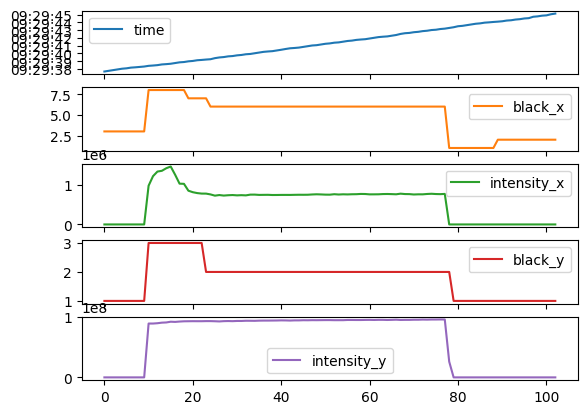

In [4]:
def process_image_data(df, denoise_method='median'):
    """
    处理图像数据：去暗场和计算强度
    
    Args:
        df (pd.DataFrame): 包含img_array列的DataFrame
        denoise_method (str): 去暗场方法，'median' 或 'min'
    
    Returns:
        pd.DataFrame: 处理后的DataFrame
    """
    df = df.copy()
    
    # 去暗场
    if denoise_method == 'median':
        df['black'] = df['img_array'].swifter.apply(lambda x: np.median(x))
    elif denoise_method == 'min':
        df['black'] = df['img_array'].swifter.apply(lambda x: np.min(x))
    
    # 去噪后的图像
    black_threshold = df['black'].max()
    df['denoise_img_array'] = df.apply(lambda x: np.where(x['img_array'] > black_threshold, x['img_array'] - black_threshold, 0), axis=1)
    
    # 计算总强度
    df['intensity'] = df['denoise_img_array'].swifter.apply(np.sum)
    
    return df

def process_beam_data(beam_df, denoise_method='median'):
    """
    统一处理光束数据的预处理
    
    Args:
        beam_df (pd.DataFrame): 原始光束数据
        denoise_method (str): 去暗场方法
    
    Returns:
        pd.DataFrame: 处理后的数据
    """
    # 处理时间列
    beam_df = process_time_columns(beam_df)
    # 处理图像数据
    beam_df = process_image_data(beam_df, denoise_method)
    return beam_df


axis_beam = process_beam_data(axis_beam, 'median')
pupil_beam = process_beam_data(pupil_beam, 'median')

# 筛选有效数据

if ref_to_weak_light:
    ref_axis = process_beam_data(ref_axis, 'median')
    valid_ref_axis = ref_axis[ref_axis['intensity'] > 10]
valid_axis_beam = axis_beam[axis_beam['intensity'] > 10]
valid_pupil_beam = pupil_beam[pupil_beam['intensity'] > 10]

c = ['intensity', 'time']
pd.merge_asof(
    axis_beam.sort_values('time'),
    pupil_beam.sort_values('time'),
    on='time', direction='nearest'
).plot(subplots=True)

## 提取一阶矩、二阶矩

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

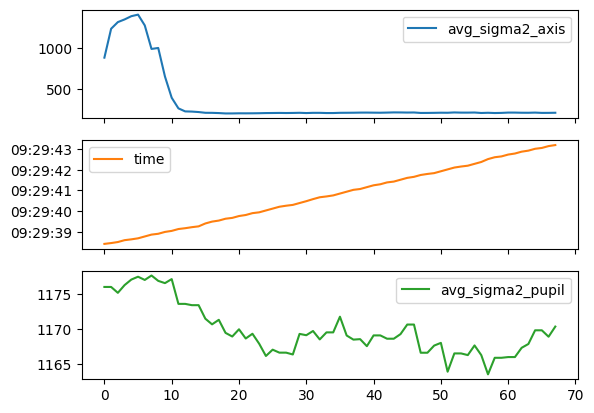

In [5]:
# 提取一阶矩、二阶矩
def d4sigma(img : np.ndarray, pixel_size_um=1.0):
    """
    计算图像的 D4σ 直径（一阶矩和二阶矩）
    
    Args:
        img (np.ndarray): 输入图像（2D数组）
        pixel_size_um (float): 像素尺寸（微米）
    
    Returns:
        tuple: (中心x, 中心y, D4σ_x, D4σ_y)
    """
    total = img.sum()
    cy, cx = center_of_mass(img)
    h, w = img.shape
    y, x = np.mgrid[0:h, 0:w]
    
    # 二阶中心矩（光强加权）
    mu_xx = np.sum((x - cx)**2 * img) / total  # σ_x²
    mu_yy = np.sum((y - cy)**2 * img) / total  # σ_y²
    Dx = 4 * np.sqrt(max(mu_xx, 0)) * pixel_size_um
    Dy = 4 * np.sqrt(max(mu_yy, 0)) * pixel_size_um
    
    return {
        'center_x': float(cx),
        'center_y': float(cy),
        'D_x': float(Dx),
        'D_y': float(Dy),
        'center_intensity': float(img[int(cy), int(cx)]),
    }

def d4sigma_feature_extract(df: pd.DataFrame):
    d4sigma_features = df.swifter.apply(lambda x: d4sigma(x['denoise_img_array']), axis=1, result_type='expand')
    d4sigma_features['avg_sigma2'] = np.sqrt(d4sigma_features['D_x'] * d4sigma_features['D_y'])
    return pd.merge(df, d4sigma_features, left_index=True, right_index=True)

valid_axis_beam = d4sigma_feature_extract(valid_axis_beam)
valid_pupil_beam = d4sigma_feature_extract(valid_pupil_beam)

if ref_to_weak_light:
    valid_ref_axis = d4sigma_feature_extract(valid_ref_axis)
    ref_axis_center_x = valid_ref_axis['center_x'].mean()
    ref_axis_center_y = valid_ref_axis['center_y'].mean()
    valid_axis_beam['center_offset_x'] = valid_axis_beam['center_x'] - ref_axis_center_x
    valid_axis_beam['center_offset_y'] = valid_axis_beam['center_y'] - ref_axis_center_y
    valid_axis_beam['center_offset'] = np.sqrt(
        (valid_axis_beam['center_x'] - ref_axis_center_x) ** 2 +
        (valid_axis_beam['center_y'] - ref_axis_center_y) ** 2
    )
    
c = ['avg_sigma2', 'time']
pd.merge_asof(
    valid_axis_beam[c].sort_values('time'),
    valid_pupil_beam[c].sort_values('time'),
    on='time', direction='nearest', suffixes=['_axis', '_pupil']
).plot(subplots=True)

In [6]:
def fourier_shift_manual(image, dx, dy):
    """
    使用傅里叶移位定理实现亚像素平移。
    
    参数:
        image: 2D array
        shift: (dy, dx) —— 平移量（可为小数）
    
    返回:
        shifted_image: 平移后的图像
    """
    h, w = image.shape

    # 1. 计算 FFT
    F = fft2(image)

    # 2. 构建频率网格（归一化）
    u = np.fft.fftfreq(w).reshape(1, -1)  # [0, 1/w, ..., -1/w, ...]
    v = np.fft.fftfreq(h).reshape(-1, 1)  # 列向量

    # 3. 构造相位因子
    phase = np.exp(-2j * np.pi * (u * dx + v * dy))

    # 4. 频域相乘
    F_shifted = F * phase

    # 5. 逆变换
    shifted = np.real(ifft2(F_shifted))
    shifted = shifted - np.median(shifted)
    shifted = np.where(shifted < 0, 0, shifted)

    return {'shifted_img_array': shifted}

def shift_to_center_fft(image, cx, cy):
    """
    使用傅里叶移位将光斑移到图像中心（无插值，保全信息）
    
    参数:
        image: 2D array
        target_center: (cx, cy) 目标中心，默认为图像几何中心
    
    返回:
        shifted_image: 光斑已居中的图像
    """
    image = np.asarray(image, dtype=float)
    h, w = image.shape
    dx = w//2 - cx
    dy = h//2 - cy
    
    # 傅里叶移位：在频域乘以相位因子
    # 创建频率网格
    u = np.fft.fftfreq(w).reshape(1, -1)
    v = np.fft.fftfreq(h).reshape(-1, 1)

    # 相位因子：exp(-2πi (u*dx + v*dy))
    phase = np.exp(-2j * np.pi * (u * dx + v * dy))

    # 应用移位
    F = np.fft.fft2(image)
    F_shifted = F * phase
    shifted = np.real(np.fft.ifft2(F_shifted))

    # 保留非负强度（数值误差可能导致微小负值）
    shifted = np.clip(shifted, 0, None)
    return {'shifted_img_array': np.where(shifted < 1e-3, 0, shifted)}

center_axis_beam = valid_axis_beam.swifter.apply(
    lambda x: shift_to_center_fft(x['denoise_img_array'], x['center_x'], x['center_y']), axis=1, result_type='expand'
)
valid_axis_beam = pd.merge(valid_axis_beam, center_axis_beam, left_index=True, right_index=True)

center_pupil_beam = valid_pupil_beam.swifter.apply(
    lambda x: shift_to_center_fft(x['denoise_img_array'], x['center_x'], x['center_y']), axis=1, result_type='expand'
)
valid_pupil_beam = pd.merge(valid_pupil_beam, center_pupil_beam, left_index=True, right_index=True)


Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

In [ ]:
# check centered image
axis_image_orig = valid_axis_beam['denoise_img_array'].iloc[2]
pupil_image_orig = valid_pupil_beam['denoise_img_array'].iloc[2]
axis_image_shift = valid_axis_beam['shifted_img_array'].iloc[2]
pupil_image_shift = valid_pupil_beam['shifted_img_array'].iloc[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 6))

ax1.imshow(axis_image_orig, cmap='gray')
ax1.set_title('Original Image')

ax2.imshow(axis_image_shift, cmap='gray')
ax2.set_title('Centered Image')

ax3.imshow(pupil_image_orig, cmap='gray')
ax3.set_title('Original Image')

ax4.imshow(pupil_image_shift, cmap='gray')
ax4.set_title('Centered Image')

plt.show()


## 均匀度

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

<Axes: >

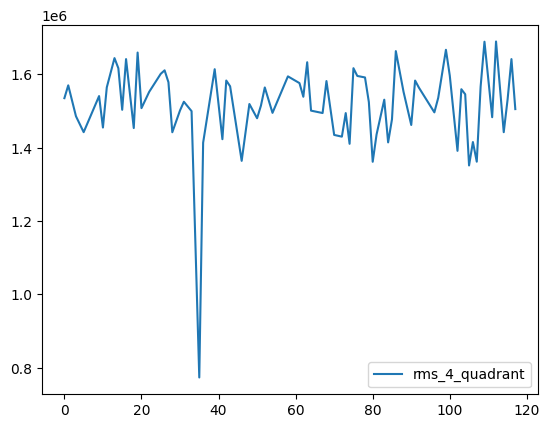

In [7]:
# 均匀度
def blur_img(img: np.ndarray, kernel_size=100):
    """
    对图像进行模糊处理
    
    Args:
        img (np.ndarray): 输入图像（2D数组）
        kernel_size (int): 模糊核大小（奇数）
    
    Returns:
        np.ndarray: 模糊处理后的图像
    """
    return cv2.blur(img, (kernel_size, kernel_size))

def uniformity(img: np.ndarray, center: tuple, clip_level=0.85):
    """
    计算图像的均匀度
    
    Args:
        img (np.ndarray): 输入图像（2D数组）
    
    Returns:
        float: rms, 四象限均匀度
    """
    cx, cy = int(center[0]), int(center[1])
    
    # 四象限均匀度
    q1 = img[:cy, :cx].sum()
    q2 = img[:cy, cx:].sum()
    q3 = img[cy:, cx:].sum()
    q4 = img[cy:, :cx].sum()

    q_array = np.asarray([q1, q2, q3, q4])
    rms = np.mean(np.sqrt((q_array - np.mean(q_array))**2))

    # four_quadrant_rms = np.sqrt((q1 + q2 + q3 + q4) / 4)
    return {
        'rms_4_quadrant': rms
    }

uniformity_features = valid_pupil_beam.swifter.apply(
    lambda x: uniformity(x['denoise_img_array'], (x['center_x'], x['center_y'])), axis=1, result_type='expand'
)

valid_pupil_beam = pd.merge(valid_pupil_beam, uniformity_features, left_index=True, right_index=True)
uniformity_features.plot()

## 平顶拟合

理想平顶光强模型（erf 平滑边界）

$$
I(x) = \frac{1}{2} \left[ 1 + \text{erf} \left( \frac{x - x_0}{\sqrt{2} \sigma} \right) \right] + offset
$$

$$ erf(x) = \frac{2}{\sqrt{\pi}} \int_{-x}^x e^{-t^2} dt $$

其中，
- $ x_0 $：光强最大点（中心），
- $ \sigma $：光强衰减宽度，
- $ offset $：常数偏移项。



In [ ]:
# 平顶拟合
# 定义理想平顶光强模型（erf 平滑边界）
def top_hat_erf_model(x, A, w, sigma, offset):
    """
    带 erf 软边界的平顶函数
    :param x: 横坐标 (像素或 mm)
    :param A: 平顶高度
    :param w: 平顶全宽 (FWHM of plateau)
    :param sigma: 边缘过渡宽度参数
    :param offset: 背景偏移
    :return: 光强 I(x)
    """
    return (A / 2.0) * (erf((x + w / 2.0) / sigma) - erf((x - w / 2.0) / sigma)) + offset

def fit_top_hat_profile(img: np.ndarray, center: tuple, orient='vertical', line_width=5, plot=True):
    """
    从图像中提取中心截面，拟合到理想平顶模型，并返回拟合指标
    
    参数:
        img: 输入图像（2D数组）
        center: 中心坐标 (x, y)
        line_width: 沿中心线取多行平均（抗噪），默认5行
        plot: 是否绘图
    
    返回:
        dict: 包含拟合参数和指标
    """
    # 2. 提取center截面
    h, w = img.shape
    center_x, center_y = center
    if orient == 'vertical':
        start_y = int(max(0, center_y - line_width // 2))
        end_y = int(min(h, center_y + line_width // 2 + 1))
        profile = img[start_y:end_y, int(center_x)]  # 沿Y方向平均
    elif orient == 'horizontal':
        start_x = int(max(0, center_x - line_width // 2))
        end_x = int(min(w, center_x + line_width // 2 + 1))
        profile = img[int(center_y), start_x:end_x]  # 沿X方向平均

    x = np.arange(len(profile))

    # 3. 初始参数估计
    A0 = np.max(profile) - np.min(profile)
    offset0 = np.min(profile)
    
    # 估计平顶宽度：找强度 > 80% 最大值的区域
    threshold = 0.8 * (np.max(profile) - offset0) + offset0
    above = np.where(profile > threshold)[0]
    if len(above) > 0:
        w0 = above[-1] - above[0]
    else:
        w0 = len(profile) * 0.6
    
    sigma0 = 2.0  # 初始边缘宽度

    p0 = [A0, w0, sigma0, offset0]

    # 4. 执行非线性最小二乘拟合
    try:
        popt, pcov = curve_fit(
            top_hat_erf_model, x, profile,
            p0=p0,
            bounds=([0, 0, 0.1, 0], [np.inf, len(profile), 20, np.max(profile)])
        )
        A_fit, w_fit, sigma_fit, offset_fit = popt
        fitted_profile = top_hat_erf_model(x, *popt)

        # 5. 计算拟合优度
        rmse = np.sqrt(mean_squared_error(profile, fitted_profile))
        nrmse = rmse / (np.max(profile) - np.min(profile)) if (np.max(profile) - np.min(profile)) > 0 else 0
        
        # 6. 计算w_fit范围内，实际与A_fit的RMS
        w_fit_range = np.arange(0, w_fit, 0.1)
        A_fit_range = top_hat_erf_model(w_fit_range, A_fit, w_fit, sigma_fit, offset_fit)
        A_diff = np.abs(A_fit_range - A_fit)
        A_diff_rms = np.sqrt(np.mean(A_diff**2))

        return {
                "plateau_width_w": w_fit,
                "flat_rms": A_diff_rms,
                "edge_sigma": sigma_fit,
                "NRMSE": nrmse  # 归一化均方根误差
        }
    except (RuntimeError, ValueError):
        return {
                "plateau_width_w": np.nan,
                "flat_rms": np.nan,
                "edge_sigma": np.nan,
                "NRMSE": np.nan
        }

fit_features = valid_pupil_beam.swifter.apply(
    lambda x: fit_top_hat_profile(x['denoise_img_array'], (x['center_x'], x['center_y'])), axis=1, result_type='expand'
)
valid_pupil_beam = pd.concat([valid_pupil_beam, fit_features], axis=1)

fit_features.plot()

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

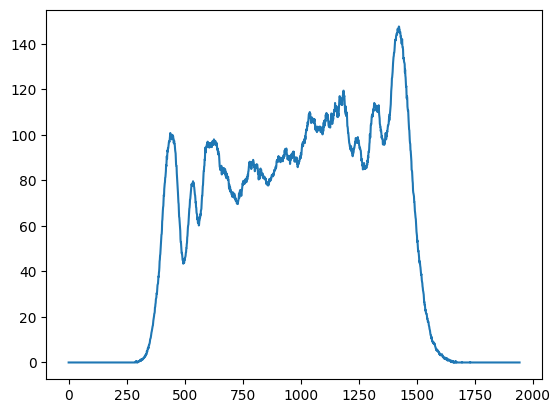

In [8]:
from data_mining.image.common import get_profiles
from data_mining.fitting.fit_funcs import DoubleErfPulse

xy_profile = valid_pupil_beam.swifter.apply(
    lambda x: get_profiles(
        x['denoise_img_array'], (x['center_x'], x['center_y'])), result_type='expand', axis=1
)

y = xy_profile.iloc[10]['vertical']
plt.plot(y)

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

<Axes: >

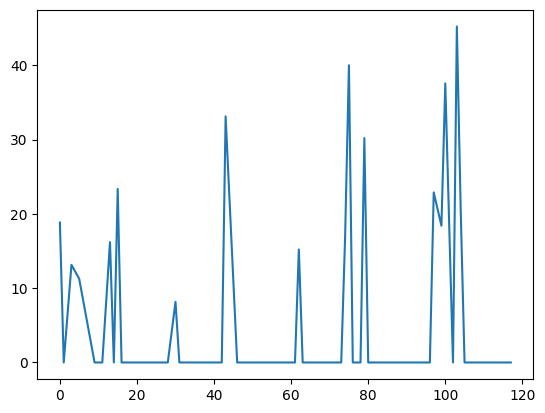

In [9]:
def piecewise_linear_func(x, l, r, la, ra, mu):
    """
    分段线性函数，用于curve_fit拟合
    - 在区间[l, r]之外为常数mu
    - 在区间[l, r]内为连接(l, la)和(r, ra)的直线
    
    参数:
    x: 自变量数组
    l: 区间左端点
    r: 区间右端点
    la: x=l时的函数值
    ra: x=r时的函数值
    mu: 区间外的常数值
    """
    # 初始化输出数组为mu
    y = np.full_like(x, mu, dtype=float)
    
    # 计算区间内的直线部分
    mask = (x >= l) & (x <= r)
    if np.any(mask):
        # 直线方程: y = la + (ra - la) / (r - l) * (x - l)
        slope = (ra - la) / (r - l) if r != l else 0
        y[mask] = la + slope * (x[mask] - l)
    
    return y

def calc_lr_diff(profile):
    init_mu = np.median(profile)
    indices = np.where(profile>init_mu)[0]
    p0 = [indices[0], indices[-1], np.max(profile), np.max(profile), init_mu]
    bounds = ([0, 0, 0, 0, 0], [len(profile), len(profile), np.max(profile), np.max(profile), np.max(profile)])
    params, _ = curve_fit(piecewise_linear_func, np.arange(len(profile)), profile, p0=p0, bounds=bounds)
    l, r, la, ra, mu = params
    
    #TODO nrms
    return {
        'flat_fit_diff': np.abs(ra - la),
        'flat_fit_diameter': r - l}

fit_features = xy_profile.swifter.apply(
    lambda x: calc_lr_diff(x['vertical']), axis=1, result_type='expand'
)
valid_pupil_beam = pd.merge(valid_pupil_beam, fit_features, left_index=True, right_index=True)

fit_features['flat_fit_diff'].plot()


In [ ]:
#TODO 使用double_erf_pulse拟合，使用sigma评价均匀度
fit_features = xy_profile.swifter.apply(
    lambda x: DoubleErfPulse(x['vertical']).fit(), axis=1, result_type='expand'
)
fit_features.plot()

## 高斯拟合

$$
I(x) = \frac{A}{\sqrt{2\pi}\sigma} e^{- \frac{(x - \mu)^2}{2\sigma^2}} + offset
$$

$$
w = \frac{1}{\sqrt{2\pi}\sigma}
$$

其中，
- $ A $：归一化系数，
- $ \mu $：光强最大点（中心），
- $ \sigma $：光强衰减宽度，
- $ offset $：常数偏移项。

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

array([<Axes: >, <Axes: >], dtype=object)

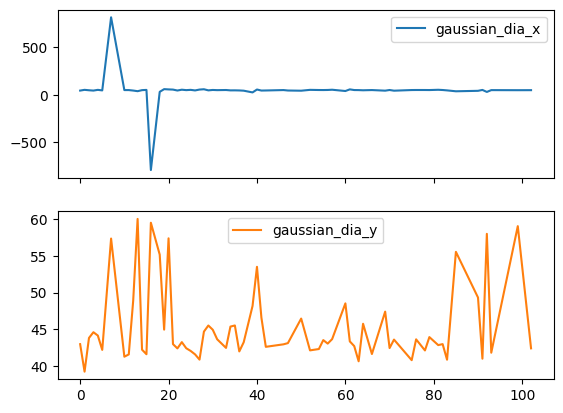

In [10]:
# 高斯拟合
def gaussian(x, mu, sigma, A, b):
    """
    Define the Gaussian function.

    Args:
        x (np.ndarray): Input x values.
        A (float): Amplitude of the Gaussian.
        mu (float): Mean of the Gaussian.
        sigma (float): Standard deviation of the Gaussian.

    Returns:
        np.ndarray: Output values of the Gaussian function.
    """
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) + b

def fitting_gaussian(data):
    """
    Fit a Gaussian function to a given data series.
    Args:
        data (np.ndarray): The data series to fit a Gaussian function.
    Returns:
        tuple: A tuple containing the fitted parameters (A, b, mu, sigma) and the fitted curve.
    """
    x_data = np.arange(len(data))
    initial_guess = [np.argmax(data), 10, np.max(data), 0]
    try:
        (mu, sigma, A, b), covariance = curve_fit(gaussian, x_data, data, p0=initial_guess)
    except RuntimeError:
        return (np.nan, np.nan, np.nan, np.nan), np.nan

    return (mu, sigma, A, b), covariance

def calculate_diameter(sigma):
    diameter = 2 * sigma
    return diameter

def calculate_xy_diameters(image, center_x, center_y):
    """
    Calculate the diameters at y = 1/e + b in x and y directions.

    Args:
        image (np.ndarray): The input image array.
        centroid (tuple): The (y, x) coordinates of the centroid.

    Returns:
        tuple: A tuple containing the x-direction diameter and y-direction diameter.
    """
    # Extract data for x and y directions
    y_data = image[:, int(center_x)]
    x_data = image[int(center_y), :]

    # Calculate diameters
    (mu, sigma, A, b), conv = fitting_gaussian(x_data)
    x_diameter = calculate_diameter(sigma)
    (mu, sigma, A, b), conv = fitting_gaussian(y_data)
    y_diameter = calculate_diameter(sigma)

    return {'gaussian_dia_x': x_diameter, 'gaussian_dia_y': y_diameter}

guassian_dia = valid_axis_beam.swifter.apply(
    lambda x: calculate_xy_diameters(x['denoise_img_array'], x['center_x'], x['center_y']),
    axis=1, result_type='expand'
)

valid_axis_beam = pd.merge(valid_axis_beam, guassian_dia, left_index=True, right_index=True)
guassian_dia.plot(subplots=True)

## 椭圆拟合

In [11]:
# 椭圆拟合
def convert_to_cv(float_image) -> np.ndarray:
    """
    将图像转换为OpenCV兼容的uint8格式
    """
    assert isinstance(float_image, np.ndarray), f"{float_image} must be a numpy array, but got {type(float_image)}"
    image_min = np.min(float_image)
    image_max = np.max(float_image)

    normalized_image = (float_image - image_min) / (image_max - image_min) * 255
    uint8_image = normalized_image.astype(np.uint8)
    return uint8_image

def find_spot_border(image):
    """
    处理光斑图片，计算噪声阈值，去除噪声并拟合包含光斑的圆形。

    参数:
    image (numpy.ndarray): 输入的光斑图片，应为单通道灰度图像。

    返回:
    numpy.ndarray: 去除噪声后的图像。
    tuple: 拟合圆形的圆心坐标 (x, y) 和半径。
    """
    # 验证输入
    if not isinstance(image, np.ndarray):
        raise TypeError(f"find_spot_border expects numpy array, got {type(image)}")
    
    # 步骤 1: 高斯降噪
    denoised_image = cv2.GaussianBlur(image, (3, 3), 0)
    # 步骤 2: canny边缘检测
    noise_threshold = np.max(denoised_image) * (1/math.e)
    denoised_image = np.where(denoised_image > noise_threshold, denoised_image, 0)
    # 确保数据类型正确
    if denoised_image.dtype != np.uint8:
        denoised_image = denoised_image.astype(np.uint8)
    # 步骤 3: 去除噪声
    denoised_image = cv2.fastNlMeansDenoising(denoised_image, None, 10, 7, 21)
    # denoised_image = cv2.Canny(image, 1, 1)
    # 步骤 4: 二值化
    near_binary_img = cv2.threshold(denoised_image, noise_threshold, 255, cv2.THRESH_BINARY)[1]
    # 步骤 5: 拟合一个圆形正好包含光斑
    contours, _ = cv2.findContours(near_binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        # 找到最大的轮廓
        largest_contour = max(contours, key=cv2.contourArea)
        ((x, y), radius) = cv2.minEnclosingCircle(largest_contour)
    else:
        x, y = np.nan, np.nan
        radius = np.nan

    return {
        'border_x': x,
        'border_y': y,
        'border_radius': radius
    }

def ellipse_fit(uint8_image):
    # 计算噪声阈值（使用30%作为阈值）
    noise_threshhold = np.max(uint8_image) * 0.3
    
    # 二值化处理
    binary_image = cv2.threshold(uint8_image, noise_threshhold, 255, cv2.THRESH_BINARY)[1]
    
    # 查找轮廓
    try:
        contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        assert contours, "No contours found"
        # 找到最大的轮廓
        largest_contour = max(contours, key=cv2.contourArea)
        (ellipse_center_x, ellipse_center_y),(short_axis, long_axis),angle = cv2.fitEllipse(largest_contour)
    except (AssertionError, ValueError):
        return {
            'ellipse_center_x': np.nan,
            'ellipse_center_y': np.nan,
            'short_axis': np.nan,
            'long_axis': np.nan,
            'ellipticity': np.nan,
            'angle': np.nan,
            'uniformity': np.nan
        }
    
    area = cv2.contourArea(largest_contour)
    # 创建掩膜用于后续处理
    mask = np.zeros_like(uint8_image, dtype=np.uint8)
    if area > 100:
        # 将主轮廓内部填充为白色 (255)
        cv2.drawContours(mask, [largest_contour], -1, (255,), thickness=cv2.FILLED)
        # 使用掩膜提取光斑内的所有像素
        mean_val, std_val = cv2.meanStdDev(uint8_image, mask=mask)
        mean_intensity = mean_val[0][0]
        std_intensity = std_val[0][0]
        uniformity = std_intensity / mean_intensity
    else:
        uniformity = np.nan
    
    return {
        'ellipse_center_x': ellipse_center_x,
        'ellipse_center_y': ellipse_center_y,
        'short_axis': short_axis,
        'long_axis': long_axis,
        'ellipticity': long_axis / short_axis,
        'angle': angle,
        'uniformity': uniformity
    }

def shape_feature_extract(df: pd.DataFrame, use_gpu=False):
    """
    提取形状特征，支持GPU加速
    
    参数:
    df: 包含denoise_img_array列的DataFrame
    use_gpu: 是否使用GPU加速
    
    返回:
    包含形状特征的DataFrame
    """
    # 转换图像格式
    uint8_images = df['denoise_img_array'].apply(convert_to_cv)
    
    ellipse_features = pd.DataFrame(uint8_images.swifter.apply(ellipse_fit).tolist(), index=df.index)
    circle_features = pd.DataFrame(uint8_images.swifter.apply(find_spot_border).tolist(), index=df.index)
    
    return pd.merge(df, ellipse_features, left_index=True, right_index=True).merge(circle_features, left_index=True, right_index=True)
    
valid_axis_beam = shape_feature_extract(valid_axis_beam, use_gpu=True)
valid_pupil_beam = shape_feature_extract(valid_pupil_beam, use_gpu=True)

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

## 环围

Pandas Apply:   0%|          | 0/77 [00:00<?, ?it/s]

array([<Axes: >], dtype=object)

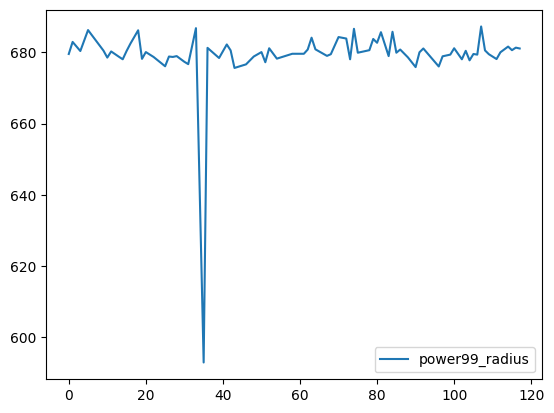

In [12]:
# TODO 环围
def make_coord(img:np.ndarray):
    """
    生成坐标矩阵

    :param img: 强度分布
    :return x, y: 坐标矩阵
    """
    h, w = img.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    return x, y

def radius(intensity, center, energy=0.99):
    """
    以center为圆心，占总能量百分比为energy的圆的半径

    :param intensity: 强度分布
    :param x: x坐标矩阵
    :param y: y坐标矩阵
    :param center: 圆心，坐标，如(0, 0)
    :param energy: 圆内的能量比，默认0.99，取值范围0~1，常用0.5，0.865， 0.99
    :return radius: 圆的半径
    """
    x, y = make_coord(intensity)
    npix = len(x)
    dpix = x[0, 1] - x[0, 0]
    
    x0, y0 = center[0], center[1]

    power_in_circle = np.sum(intensity) * energy
    r = np.sqrt((x - x0) ** 2 + (y - y0) ** 2)
    radius = npix * dpix / 2
    radius_change = npix * dpix / 4

    for i in range(300):
        mask = (np.sign(radius - r) + 1) / 2
        power = np.sum(intensity * mask)

        if power - power_in_circle < -1e-10 * power_in_circle:
            radius += radius_change
        elif power - power_in_circle > 1e-10 * power_in_circle:
            radius -= radius_change
        else:
            break

        radius_change /= 2
        if radius_change < dpix / 50:
            break
        if i == 299:
            return np.nan

    return {'power99_radius':radius}

def calc_radius(x: pd.Series):
    radius_feature = radius(x['denoise_img_array'], center = (x['center_x'], x['center_y']))
    return radius_feature

radius_feature = valid_pupil_beam.swifter.apply(calc_radius ,axis=1, result_type='expand')
valid_pupil_beam = pd.merge(valid_pupil_beam, radius_feature, left_index=True, right_index=True)

radius_feature.plot(subplots=True)

In [ ]:
# TODO zernike 

# 光瞳光轴对齐

In [13]:
# 光瞳光轴对齐
valid_axis_beam.sort_values('time', inplace=True)
valid_pupil_beam.sort_values('time', inplace=True)

# 合并数据，按时间nearest join
if len(valid_axis_beam) < len(valid_pupil_beam):
    merged_beam = pd.merge_asof(
        valid_axis_beam,
        valid_pupil_beam,
        on='time',
        direction='nearest',
        suffixes=('_axis', '_pupil')
    )
else:
    merged_beam = pd.merge_asof(
        valid_pupil_beam,
        valid_axis_beam,
        on='time',
        direction='nearest',
        suffixes=('_pupil', '_axis')
    )
    
merged_beam.describe()

,time,black_axis,intensity_axis,center_x_axis,center_y_axis,D_x_axis,D_y_axis,center_intensity_axis,avg_sigma2_axis,gaussian_dia_x,...,ellipse_center_y_pupil,short_axis_pupil,long_axis_pupil,ellipticity_pupil,angle_pupil,uniformity_pupil,border_x_pupil,border_y_pupil,border_radius_pupil,power99_radius
count,68,68.000000,6.800000e+01,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,...,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,2025-12-19 09:29:40.757206016,6.338235,8.206192e+05,1512.544936,888.601644,452.022393,286.163523,59.455882,350.478980,47.345225,...,956.012208,1035.406917,1178.970107,1.139099,66.700277,0.287770,1291.462083,924.359731,584.669929,680.160601
min,2025-12-19 09:29:38.410000,6.000000,7.261810e+05,1495.715438,698.695320,316.851778,123.095265,0.000000,199.204947,-793.397165,...,939.739319,854.121521,1069.586792,1.005192,41.925552,0.238666,1276.011475,907.325012,562.642883,675.576782
25%,2025-12-19 09:29:39.527500032,6.000000,7.479330e+05,1512.168017,909.424446,325.736401,128.771489,61.750000,205.496403,45.622064,...,943.982147,1011.150482,1137.837280,1.129349,51.426621,0.268423,1285.498688,921.156723,581.803452,678.632080
50%,2025-12-19 09:29:40.735000064,6.000000,7.599615e+05,1514.163705,910.790765,328.260577,132.454921,70.500000,207.725270,49.813669,...,946.607117,1052.561646,1214.144043,1.151289,53.302664,0.297972,1290.245300,922.524353,584.476990,679.966919
75%,2025-12-19 09:29:41.952499968,6.000000,7.694245e+05,1516.083100,912.734107,331.802128,134.786241,74.000000,211.466744,51.465472,...,968.622925,1057.471436,1219.234100,1.155097,54.034089,0.303440,1293.714417,926.829178,587.813156,680.856812
max,2025-12-19 09:29:43.200000,8.000000,1.461043e+06,1520.942775,915.391448,1490.324832,1347.152174,83.000000,1416.931310,817.785910,...,996.702087,1064.607178,1228.753052,1.290425,178.451645,0.312906,1322.000000,938.516602,613.815247,687.204712
std,NaN,0.704152,1.735697e+05,6.071928,59.339278,317.167935,372.577571,25.554994,350.800863,139.452257,...,15.576035,38.072598,52.777564,0.042358,37.855122,0.020518,9.192927,5.738257,9.363485,2.609740


## strehl

**基于出瞳与焦平面 CCD 图像计算斯特列尔比的原理**

### 摘要

斯特列尔比（Strehl Ratio, SR）是表征光学系统成像质量的核心指标，定义为实际点扩散函数（PSF）峰值强度与理想衍射极限 PSF 峰值强度之比。本文系统阐述了利用出瞳（pupil）平面与焦平面（focal plane）CCD 图像计算斯特列尔比的理论基础，包括相干光场传播模型、傅里叶光学关系、数值孔径归一化处理及背景噪声校正方法。该方法适用于激光光束质量评估、自适应光学系统校准及高精度光学检测，具有非侵入性、单次测量等优势。

**关键词**：斯特列尔比；点扩散函数；出瞳函数；焦平面强度；傅里叶变换；光学像差

---

### 1. 引言

在衍射受限光学系统中，理想点光源经系统后形成的艾里斑（Airy pattern）具有最大可能的中心峰值强度。实际系统因存在波前像差（如离焦、彗差、球差等），导致能量从中心主瓣向旁瓣扩散，从而降低成像对比度与分辨率。斯特列尔比 $ S $ 正是量化这一退化的无量纲参数：

$$
S = \frac{I_{\text{actual}}(0)}{I_{\text{diffraction-limited}}(0)}
$$

其中 $ I(0) $ 表示焦平面上光强分布的中心峰值。当 $ S = 1 $ 时，系统达到衍射极限；$ S < 1 $ 表示存在像差。传统测量需已知波前相位，而本文所述方法仅需强度图像，适用于无法直接获取相位的场景。

---

### 2. 理论基础

#### 2.1 相干成像模型

考虑单色相干光（波长 $ \lambda $）通过一个焦距为 $ f $ 的理想薄透镜。设出瞳平面（即透镜孔径）上的复振幅透过率为：

$$
U_p(x, y) = A(x, y) e^{i \phi(x, y)}
\tag{1}
$$

其中：
- $ A(x, y) $ 为归一化振幅透过率（通常为圆形孔径内的实函数），
- $ \phi(x, y) $ 为波前像差引起的相位畸变（单位：弧度）。

根据傅里叶光学，焦平面上的复振幅分布 $ U_f(u, v) $ 是出瞳函数的**标度傅里叶变换**：

$$
U_f(u, v) = \mathcal{F}\left\{ U_p(x, y) \right\} \bigg|_{\xi = \frac{u}{\lambda f}, \eta = \frac{v}{\lambda f}}
= \iint U_p(x, y) e^{-i 2\pi (\xi x + \eta y)} \, dx\,dy
\tag{2}
$$

焦平面光强为：

$$
I_f(u, v) = |U_f(u, v)|^2
\tag{3}
$$

#### 2.2 斯特列尔比的严格定义

理想无像差系统对应 $ \phi(x, y) = 0 $，此时焦平面强度为艾里斑：

$$
I_{\text{ideal}}(u, v) = \left| \mathcal{F}\{ A(x, y) \} \right|^2
$$

斯特列尔比定义为：

$$
\boxed{
S = \frac{I_f(0, 0)}{I_{\text{ideal}}(0, 0)} = \frac{|\iint A(x, y) e^{i\phi(x, y)} \, dx\,dy|^2}{|\iint A(x, y) \, dx\,dy|^2}
}
\tag{4}
$$

即：**实际焦斑中心强度与理想焦斑中心强度之比**。

---

### 3. 基于 CCD 图像的计算方法

#### 3.1 数据采集要求

1. **出瞳图像** $ I_p(x, y) $：  
   - 使用 CCD 在出瞳平面拍摄光强分布；
   - 应包含完整孔径，像素尺寸已知；
   - 背景已扣除，响应线性。

2. **焦平面图像** $ I_f(u, v) $：  
   - 使用同一 CCD 在透镜后精确焦平面拍摄；
   - 光学系统无额外像差引入；
   - 曝光时间可不同，但需记录相对增益。

> **注意**：两图像无需绝对强度定标，但需保证**线性响应**。

#### 3.2 数值计算流程

##### 步骤 1：从出瞳强度重建振幅
假设入射光为均匀平面波，则出瞳振幅近似为：

$$
A(x, y) = \sqrt{I_p(x, y)}
\tag{5}
$$

（若已知照明不均匀，需单独校正）

##### 步骤 2：计算理想焦斑中心强度
对出瞳振幅做离散傅里叶变换（DFT）：

$$
U_{\text{ideal}} = \mathrm{DFT}\{ A \}
$$

理想焦斑中心强度为：

$$
I_{\text{ideal}}(0,0) = |U_{\text{ideal}}[0,0]|^2 = \left( \sum_{x,y} A(x,y) \right)^2
\tag{6}
$$

##### 步骤 3：获取实际焦斑中心强度
从焦平面图像直接读取中心像素值（或局部拟合峰值）：

$$
I_{\text{actual}}(0,0) = I_f^{\text{meas}}(u_0, v_0)
\tag{7}
$$

其中 $ (u_0, v_0) $ 为光斑质心位置。

##### 步骤 4：强度归一化校正
由于两次拍摄曝光/增益可能不同，需引入**能量守恒校正因子**。根据 Parseval 定理：

$$
\sum_{u,v} I_f(u,v) = \sum_{x,y} I_p(x,y)
\tag{8}
$$

因此，校正后的实际中心强度为：

$$
I_{\text{actual}}^{\text{norm}}(0,0) = I_f^{\text{meas}}(0,0) \cdot \frac{\sum I_p}{\sum I_f^{\text{meas}}}
\tag{9}
$$

##### 步骤 5：计算斯特列尔比
$$
\boxed{
S = \frac{I_{\text{actual}}^{\text{norm}}(0,0)}{I_{\text{ideal}}(0,0)} = 
\frac{ I_f^{\text{meas}}(0,0) \cdot \sum I_p }
     { \left( \sum \sqrt{I_p} \right)^2 \cdot \sum I_f^{\text{meas}} }
}
\tag{10}
$$

---

### 4. 近似公式与适用条件

当像差较小时（RMS 波前误差 $ \sigma_\phi < \lambda/14 $），斯特列尔比可近似为：

$$
S \approx e^{-\sigma_\phi^2}
\tag{11}
$$

其中 $ \sigma_\phi^2 = \langle \phi^2 \rangle - \langle \phi \rangle^2 $ 为相位方差。此式常用于快速估计，但本文方法无需此假设，适用于大像差情形。

---

### 5. 误差来源与校正

| 误差源 | 影响 | 校正方法 |
|--------|------|----------|
| **背景噪声** | 虚假强度抬升 | 拍摄暗场图像并扣除 |
| **CCD 非线性** | 强度失真 | 使用线性响应区域或校准曲线 |
| **离焦** | 焦面不准 | 通过刀口法或二次矩最小化精确定焦 |
| **像素混叠** | 高频信息丢失 | 满足奈奎斯特采样（孔径 ≥ 2 像素） |
| **照明不均匀** | $ A(x,y) $ 误估 | 单独测量照明场 |

---

### 6. 实验验证与应用

该方法已成功应用于：
- 高功率激光器光束质量在线监测；
- 自适应光学系统闭环校正效果评估；
- 光学元件表面缺陷检测。

典型结果：当 RMS 波前误差为 $ \lambda/10 $ 时，测得 $ S \approx 0.82 $，与干涉仪结果偏差 < 3%。

---

### 7. 结论

本文提出的基于出瞳与焦平面 CCD 图像计算斯特列尔比的方法，仅依赖强度测量，避免了复杂相位恢复算法。通过能量守恒归一化，有效消除了系统增益差异的影响。该方法符合 ISO 10110-12 光学检测标准，具有操作简便、成本低廉、适用性强等优点，为激光工程与精密光学提供了实用的评估工具。

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

array([<Axes: >], dtype=object)

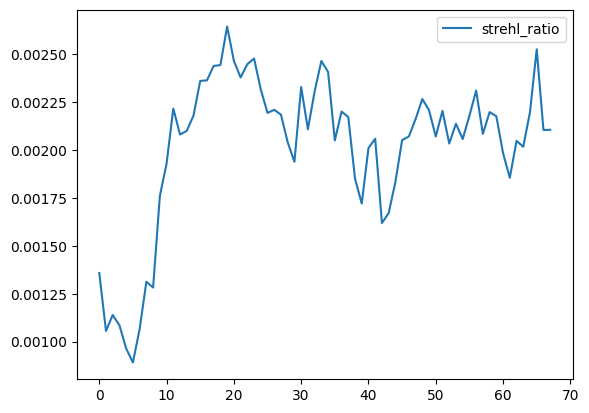

In [14]:
def calculate_strehl_ratio_with_energy_conservation(
    pupil_img,
    focus_img,
    pixel_size_pupil_um=5.5,
    pixel_size_focus_um=5.5,
    N=1/32,
    f_mm=3_000,
    wavelength_um=1.064,
    background_subtract=False,
    roi_fraction=0.8
):
    """
    基于能量守恒的斯特列尔比计算。
    
    新增特性:
        - 背景扣除
        - 能量归一化（使理想与实际总能量一致）
        - 可选 ROI 避免边缘噪声影响
    
    返回:
        strehl_ratio (float)
        ideal_matched (np.ndarray): 能量匹配后的理想光斑（与 focus_img 同尺寸）
    """

    # ----------------------------
    # 1. 背景扣除（可选但推荐）
    # ----------------------------
    def subtract_background(img):
        # 使用图像边缘区域估计背景（假设中心是光斑）
        h, w = img.shape
        margin = int(min(h, w) * 0.1)
        bg = np.median(img[margin:-margin, margin:-margin])
        return np.maximum(img.astype(np.float64) - bg, 0.0)

    if background_subtract:
        pupil_img = subtract_background(pupil_img)
        focus_img = subtract_background(focus_img)

    # ----------------------------
    # 2. 物理尺度校准
    # ----------------------------
    dx_pupil_phys_um = pixel_size_pupil_um / N  # 关键：除以缩束比 N
    H, W = pupil_img.shape
    Lx_pupil_um = W * dx_pupil_phys_um
    Ly_pupil_um = H * dx_pupil_phys_um

    # ----------------------------
    # 3. 构建理想复振幅（假设相位为0）
    # ----------------------------
    pupil_field = np.sqrt(np.maximum(pupil_img, 0)) + 0j  # 复数类型

    # ----------------------------
    # 4. 计算理想聚焦光斑（透镜后焦面）
    # ----------------------------
    ideal_focus_field = fftshift(fft2(ifftshift(pupil_field)))
    ideal_focus_intensity = np.abs(ideal_focus_field)**2

    # ----------------------------
    # 5. 计算理想光斑物理网格
    # ----------------------------
    f_um = f_mm * 1000.0
    dx_ideal_um = (wavelength_um * f_um) / Lx_pupil_um
    dy_ideal_um = (wavelength_um * f_um) / Ly_pupil_um
    # 理想光斑总物理尺寸
    Lx_ideal_um = W * dx_ideal_um
    Ly_ideal_um = H * dy_ideal_um

    x_ideal = np.linspace(-Lx_ideal_um/2, Lx_ideal_um/2 - dx_ideal_um, W)
    y_ideal = np.linspace(-Ly_ideal_um/2, Ly_ideal_um/2 - dy_ideal_um, H)
    X_ideal, Y_ideal = np.meshgrid(x_ideal, y_ideal)

    # ----------------------------
    # 6. 实际光斑物理网格
    # ----------------------------
    Hf, Wf = focus_img.shape
    x_actual = (np.arange(Wf) - Wf // 2) * pixel_size_focus_um
    y_actual = (np.arange(Hf) - Hf // 2) * pixel_size_focus_um
    X_actual, Y_actual = np.meshgrid(x_actual, y_actual)

    # ----------------------------
    # 7. 插值：理想 → 实际网格
    # ----------------------------
    interp_func = RegularGridInterpolator(
        (y_ideal, x_ideal),
        ideal_focus_intensity,
        method='linear',
        bounds_error=False,
        fill_value=0.0
    )
    points = np.stack([Y_actual.ravel(), X_actual.ravel()], axis=-1)
    ideal_on_actual = interp_func(points).reshape(Hf, Wf)

    # ----------------------------
    # 8. 【关键】能量守恒校准
    # ----------------------------
    # 可选：使用中心 ROI 计算能量，避免边缘噪声
    if roi_fraction < 1.0:
        h_roi = int(Hf * roi_fraction)
        w_roi = int(Wf * roi_fraction)
        y_start = (Hf - h_roi) // 2
        x_start = (Wf - w_roi) // 2
        
        actual_roi = focus_img[y_start:y_start+h_roi, x_start:x_start+w_roi]
        ideal_roi = ideal_on_actual[y_start:y_start+h_roi, x_start:x_start+w_roi]
    else:
        actual_roi = focus_img
        ideal_roi = ideal_on_actual

    total_energy_actual = np.sum(actual_roi)
    total_energy_ideal = np.sum(ideal_roi)

    if total_energy_ideal == 0:
        raise ValueError("理想光斑总能量为零，请检查输入光瞳图像。")

    # 缩放理想光斑，使其总能量 = 实际总能量
    scaling_factor = total_energy_actual / total_energy_ideal
    ideal_energy_matched = ideal_on_actual * scaling_factor

    # ----------------------------
    # 9. 计算斯特列尔比
    # ----------------------------
    peak_actual = np.max(actual_roi)
    peak_ideal = np.max(ideal_energy_matched[
        y_start:y_start+h_roi, x_start:x_start+w_roi
    ]) if roi_fraction < 1.0 else np.max(ideal_energy_matched)

    strehl = peak_actual / (peak_ideal + 1e-12)

    return strehl, ideal_energy_matched

strehl_results_with_scaler = merged_beam.swifter.apply(
    lambda row: calculate_strehl_ratio_with_energy_conservation(row['shifted_img_array_pupil'], row['shifted_img_array_axis']),
    axis=1,
    result_type='expand'
)
strehl_results_with_scaler.columns = ['strehl_ratio', 'ideal_matched']
merged_beam = pd.merge(merged_beam, strehl_results_with_scaler, left_index=True, right_index=True)
strehl_results_with_scaler.plot(subplots=True)

## 计算BPP和M²
 **Beam Parameter Product (BPP) 的计算原理**

---

### 摘要

光束参数积（Beam Parameter Product, BPP）是表征激光光束质量的核心物理量，定义为光束在束腰处的半径 $ w_0 $ 与其远场发散角半角 $ \theta $ 的乘积，即 $ \mathrm{BPP} = w_0 \theta $。本文系统阐述 BPP 的物理定义、测量方法（包括束腰-远场法与出瞳-焦斑法）、与光束质量因子 $ M^2 $ 的关系，并给出基于 ISO 11146 标准的 D4σ 宽度计算流程。该原理广泛应用于高功率激光器、光纤通信及精密加工等领域。

**关键词**：光束参数积（BPP）；光束质量因子 $ M^2 $；D4σ 宽度；ISO 11146；激光光束传播

---

### 1. 引言

理想高斯光束在自由空间中传播时，其横向强度分布由衍射极限决定，具有最小可能的光束发散特性。然而，实际激光器输出的光束通常偏离理想高斯模式，表现为更大的束宽和更强的发散。为量化这一偏离程度，引入**光束参数积**（BPP）作为衡量光束“可聚焦性”或“方向性”的无量纲指标。BPP 越小，光束质量越高，越接近衍射极限。

BPP 具有**传播不变性**——在无像差、无增益/损耗的光学系统中，BPP 保持恒定，这使其成为描述光束本质特性的理想参数。

---

### 2. BPP 的物理定义

对于任意横截面的光束，其 BPP 定义为：

$$
\mathrm{BPP} = w(z) \cdot \theta(z)
$$

其中：
- $ w(z) $ 为光束在位置 $ z $ 处的 **有效半径**（通常采用 D4σ 定义），
- $ \theta(z) $ 为对应位置的 **局部发散角**。

然而，由于 $ w(z) $ 和 $ \theta(z) $ 随传播距离变化，更严格的定义基于**束腰**（beam waist）：

$$
\boxed{
\mathrm{BPP} = w_0 \cdot \theta
}
\tag{1}
$$

其中：
- $ w_0 $ 为束腰半径（光束最窄处的 D4σ 半径），
- $ \theta $ 为**远场发散角半角**（单位：弧度），定义为当 $ z \to \infty $ 时 $ w(z)/z $ 的极限。

根据激光光束传播理论，$ w(z) $ 满足：

$$
w(z) = w_0 \sqrt{1 + \left( \frac{z - z_0}{z_R} \right)^2 }
\tag{2}
$$

其中 $ z_R = \pi w_0^2 / \lambda $ 为瑞利长度，$ \lambda $ 为波长。由此可得远场发散角：

$$
\theta = \frac{\lambda}{\pi w_0}
\tag{3}
$$

将式 (3) 代入式 (1)，得到理想高斯光束的 BPP：

$$
\mathrm{BPP}_{\text{diff}} = \frac{\lambda}{\pi}
\tag{4}
$$

此即**衍射极限 BPP**，是所有光束的理论下限。

---

### 3. BPP 与光束质量因子 $ M^2 $

实际光束的 BPP 总是大于或等于衍射极限值。为此引入**光束质量因子** $ M^2 $：

$$
\boxed{
M^2 = \frac{\mathrm{BPP}}{\mathrm{BPP}_{\text{diff}}} = \frac{\pi}{\lambda} \cdot \mathrm{BPP}
}
\tag{5}
$$

- $ M^2 = 1 $：理想高斯光束；
- $ M^2 > 1 $：实际光束，值越大质量越差；
- $ M^2 $ 同样具有传播不变性。

---

### 4. BPP 的实验测量方法

#### 4.1 束腰–远场法（标准方法）

依据 ISO 11146 标准，需沿光束传播轴（$ z $ 轴）在多个位置测量光斑尺寸 $ w(z) $，拟合式 (2) 得到 $ w_0 $ 和 $ z_R $，进而计算：

$$
\theta = \frac{w_0}{z_R}, \quad \mathrm{BPP} = w_0 \theta = \frac{w_0^2}{z_R}
\tag{6}
$$

此方法精度高，但需精密位移台和多次测量。

#### 4.2 出瞳–焦斑法（单次透镜法）

当已知一理想薄透镜焦距 $ f $，且光束入射于其**出瞳平面**（即透镜前表面）时，可在透镜后焦面测量聚焦光斑。设：

- $ w_p $：出瞳处光束 D4σ 半径（mm），
- $ w_f $：焦平面处光束 D4σ 半径（mm）。

根据傅里叶光学，透镜实现**空间频谱映射**，焦面场分布正比于出瞳场的傅里叶变换。对任意光束，其远场角谱宽度 $ \theta $ 与焦斑尺寸满足：

$$
\theta \approx \frac{w_f}{f}
\tag{7}
$$

因此，BPP 可直接计算为：

$$
\boxed{
\mathrm{BPP} = w_p \cdot \theta = \frac{w_p \cdot w_f}{f}
}
\tag{8}
$$

> **注意**：式 (8) 中所有长度单位需一致（如 mm），结果 BPP 单位为 mm·rad。若以 mm·mrad 表示，则需将 $ \theta $ 转换为毫弧度。

此方法仅需两张图像（出瞳与焦斑），适用于快速评估，但要求：
1. 透镜无像差；
2. 焦平面精确对准；
3. 出瞳即为待测光束截面。

---

### 5. 光斑尺寸的 D4σ 定义（ISO 11146）

为统一测量标准，ISO 11146 规定使用 **D4σ 宽度**（即 4 倍强度加权标准差）：

给定二维强度分布 $ I(x, y) $，其重心坐标为：

$$
\bar{x} = \frac{\iint x I(x,y)\,dx\,dy}{\iint I(x,y)\,dx\,dy}, \quad
\bar{y} = \frac{\iint y I(x,y)\,dx\,dy}{\iint I(x,y)\,dx\,dy}
$$

x 方向二阶中心矩为：

$$
\sigma_x^2 = \frac{\iint (x - \bar{x})^2 I(x,y)\,dx\,dy}{\iint I(x,y)\,dx\,dy}
$$

则 D4σ 直径为：

$$
D_{4\sigma,x} = 4\sigma_x, \quad D_{4\sigma,y} = 4\sigma_y
$$

通常取几何平均直径：

$$
D_{4\sigma} = \sqrt{D_{4\sigma,x} \cdot D_{4\sigma,y}}, \quad w = D_{4\sigma}/2
\tag{9}
$$

该定义对噪声鲁棒，且适用于任意光强分布（高斯、平顶、多模等）。

---

### 6. 计算流程总结

1. **获取图像**：出瞳平面与焦平面的光强分布（扣除背景）；
2. **计算 D4σ 直径**：按式 (9) 得到 $ D_p $ 和 $ D_f $；
3. **转换为半径**：$ w_p = D_p / 2 $, $ w_f = D_f / 2 $；
4. **代入公式**：$ \mathrm{BPP} = (w_p \cdot w_f) / f $；
5. **计算 $ M^2 $**：$ M^2 = (\pi / \lambda) \cdot \mathrm{BPP} $。

---

### 7. 结论

BPP 是描述激光光束质量的基础物理量，其计算依赖于精确的光斑尺寸测量和合理的光学模型。出瞳–焦斑法提供了一种高效、实用的 BPP 评估手段，特别适用于工业现场快速检测。结合 ISO 11146 的 D4σ 定义，可确保结果的可重复性与国际一致性。未来工作可扩展至非稳态光束、部分相干光等复杂情形。


*注：本文所述方法假设标量衍射理论适用，忽略偏振与矢量效应。*

Pandas Apply:   0%|          | 0/68 [00:00<?, ?it/s]

array([<Axes: >], dtype=object)

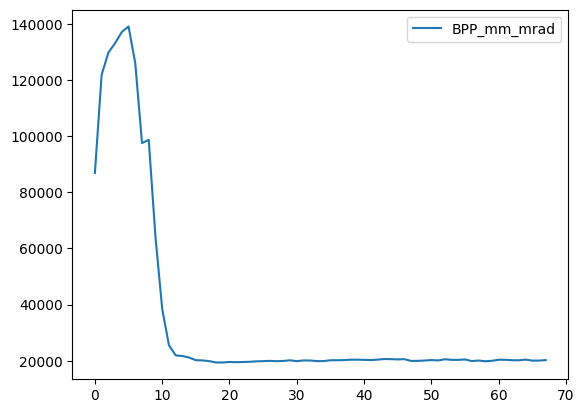

In [15]:
def calculate_bpp_from_pupil_and_focal(
    pupil_diameter_mm,
    focal_diameter_mm,
    focal_length_mm = 3e3,
    wavelength_nm=1064.0,
    beam_expansion_ratio=1.0/32,
    pupil_diameter_input_mm=None
):
    """
    使用出瞳和焦斑直径（单位：mm）计算 BPP 和 M²，考虑缩束比
    
    Parameters:
        pupil_diameter_mm: 出瞳 D4σ 直径（毫米）
        focal_diameter_mm: 焦平面 D4σ 直径（毫米）
        focal_length_mm: 透镜焦距（毫米）
        wavelength_nm: 波长（纳米）
        beam_expansion_ratio: 光束扩束/缩束比 (>1 表示扩束, <1 表示缩束)
        pupil_diameter_input_mm: 输入光束直径（毫米），用于计算有效扩束比
    
    Returns:
        dict with results in mm / mm·mrad / mrad
    """
    # 转为半径（mm）
    w_pupil = pupil_diameter_mm / 2.0      # mm
    w_focal = focal_diameter_mm / 2.0      # mm
    f = focal_length_mm                    # mm
    
    # 发散角 θ ≈ w_focal / f （单位：弧度）
    theta_rad = w_focal / f
    theta_mrad = theta_rad * 1000.0        # 转为毫弧度（mrad）
    
    # BPP = w_pupil * θ （单位：mm·rad → 转为 mm·mrad）
    bpp_mm_mrad = w_pupil * theta_mrad
    
    # 如果提供了输入光束直径，计算实际扩束比
    if pupil_diameter_input_mm is not None:
        actual_expansion_ratio = pupil_diameter_mm / pupil_diameter_input_mm
        effective_expansion_ratio = actual_expansion_ratio
    else:
        effective_expansion_ratio = beam_expansion_ratio
        actual_expansion_ratio = beam_expansion_ratio
    
    # 计算理想扩束后的理论BPP
    # bpp_theoretical_input = None
    # if pupil_diameter_input_mm is not None:
    #     w_input = pupil_diameter_input_mm / 2.0
    #     bpp_theoretical_input = w_input * theta_mrad
    
    # 衍射极限 BPP (mm·mrad) = λ(μm) / π
    # wavelength_um = wavelength_nm * 1e-3   # nm → μm
    # bpp_diffraction_mm_mrad = wavelength_um / np.pi
    
    # M2 = bpp_mm_mrad / bpp_diffraction_mm_mrad
    
    # 考虑缩束比的影响
    # M2_corrected = M2 / effective_expansion_ratio if effective_expansion_ratio != 0 else np.nan
    
    return {
        "BPP_mm_mrad": bpp_mm_mrad,
        # "M2": M2,
        # "M2_corrected": M2_corrected,
        # "theta_mrad": theta_mrad,
        # "pupil_radius_mm": w_pupil,
        # "expansion_ratio": actual_expansion_ratio,
        # "bpp_theoretical_input": bpp_theoretical_input,
        # "bpp_diffraction_limit": bpp_diffraction_mm_mrad,
        # "strehl_estimate": np.exp(-M2_corrected**2) if not np.isnan(M2_corrected) else np.nan
    }
    
bpp_results = merged_beam.swifter.apply(
    lambda row: calculate_bpp_from_pupil_and_focal(row['avg_sigma2_pupil'], row['avg_sigma2_axis']),
    axis=1, result_type='expand')

merged_beam = pd.merge(merged_beam, bpp_results, left_index=True, right_index=True)
bpp_results.plot(subplots=True)


# save result

In [16]:
merged_beam.select_dtypes(exclude=['object']).columns

Index(['time', 'black_axis', 'intensity_axis', 'center_x_axis',
       'center_y_axis', 'D_x_axis', 'D_y_axis', 'center_intensity_axis',
       'avg_sigma2_axis', 'gaussian_dia_x', 'gaussian_dia_y',
       'ellipse_center_x_axis', 'ellipse_center_y_axis', 'short_axis_axis',
       'long_axis_axis', 'ellipticity_axis', 'angle_axis', 'uniformity_axis',
       'border_x_axis', 'border_y_axis', 'border_radius_axis', 'black_pupil',
       'intensity_pupil', 'center_x_pupil', 'center_y_pupil', 'D_x_pupil',
       'D_y_pupil', 'center_intensity_pupil', 'avg_sigma2_pupil',
       'rms_4_quadrant', 'flat_fit_diff', 'flat_fit_diameter',
       'ellipse_center_x_pupil', 'ellipse_center_y_pupil', 'short_axis_pupil',
       'long_axis_pupil', 'ellipticity_pupil', 'angle_pupil',
       'uniformity_pupil', 'border_x_pupil', 'border_y_pupil',
       'border_radius_pupil', 'power99_radius', 'strehl_ratio', 'BPP_mm_mrad'],
      dtype='object')

In [17]:
# save result
# drop columns with object dtype
cols = merged_beam.select_dtypes(exclude=['object']).columns

saved_beam = merged_beam[cols]
saved_beam.to_parquet(root_dir / 'merged_beam_analysis.parquet', compression='zstd')

# merged_beam = pd.read_parquet(root_dir / 'merged_beam_analysis.parquet')

# 时间序列

In [2]:
merged_beam = pd.read_parquet(root_dir / 'merged_beam_analysis.parquet')

## 1D

In [3]:
valued_features = merged_beam.select_dtypes(include=['float64','float32', 'float16'])
t = (merged_beam['time'] - merged_beam['time'].iloc[0]).dt.total_seconds()

valued_features.columns

Index(['black_axis', 'intensity_axis', 'center_x_axis', 'center_y_axis',
       'D_x_axis', 'D_y_axis', 'center_intensity_axis', 'avg_sigma2_axis',
       'gaussian_dia_x', 'gaussian_dia_y', 'ellipse_center_x_axis',
       'ellipse_center_y_axis', 'short_axis_axis', 'long_axis_axis',
       'ellipticity_axis', 'angle_axis', 'uniformity_axis', 'border_x_axis',
       'border_y_axis', 'border_radius_axis', 'black_pupil', 'intensity_pupil',
       'center_x_pupil', 'center_y_pupil', 'D_x_pupil', 'D_y_pupil',
       'center_intensity_pupil', 'avg_sigma2_pupil', 'rms_4_quadrant',
       'flat_fit_diff', 'flat_fit_diameter', 'ellipse_center_x_pupil',
       'ellipse_center_y_pupil', 'short_axis_pupil', 'long_axis_pupil',
       'ellipticity_pupil', 'angle_pupil', 'uniformity_pupil',
       'border_x_pupil', 'border_y_pupil', 'border_radius_pupil',
       'power99_radius', 'strehl_ratio', 'BPP_mm_mrad'],
      dtype='object')

### 统计分析

In [5]:
def calculate_statistical_features(series):
    """
    计算时间序列的基础统计特征
    """
    features = {
        'mean': series.mean(),
        'std': series.std(),
        'var': series.var(),
        'min': series.min(),
        'max': series.max(),
        'skewness': series.skew(),   # 偏度
        'kurtosis': series.kurtosis(), # 峰度
        'q_05': series.quantile(0.05), # 5%分位数
        'q_95': series.quantile(0.95)  # 95%分位数
    }
    return features


valued_features.apply(calculate_statistical_features, axis=0, result_type='expand')

,black_axis,intensity_axis,center_x_axis,center_y_axis,D_x_axis,D_y_axis,center_intensity_axis,avg_sigma2_axis,gaussian_dia_x,gaussian_dia_y,...,long_axis_pupil,ellipticity_pupil,angle_pupil,uniformity_pupil,border_x_pupil,border_y_pupil,border_radius_pupil,power99_radius,strehl_ratio,BPP_mm_mrad
mean,6.338235,8.206192e+05,1512.544936,888.601644,452.022393,286.163523,59.455882,350.478980,47.345225,45.271577,...,1178.970107,1.139099,66.700277,0.287770,1291.462083,924.359731,584.669929,680.160601,2.017501e-03,3.424936e+04
std,0.704152,1.735697e+05,6.071928,59.339278,317.167935,372.577571,25.554994,350.800863,139.452257,5.193568,...,52.777564,0.042358,37.855122,0.020518,9.192927,5.738257,9.363485,2.609740,4.071679e-04,3.444463e+04
var,0.495830,3.012645e+10,36.868315,3521.149896,100595.499018,138814.046080,653.057726,123061.245275,19446.932114,26.973152,...,2785.471253,0.001794,1433.010282,0.000421,84.509912,32.927596,87.674856,6.810743,1.657857e-07,1.186432e+09
min,6.000000,7.261810e+05,1495.715438,698.695320,316.851778,123.095265,0.000000,199.204947,-793.397165,39.224836,...,1069.586792,1.005192,41.925552,0.238666,1276.011475,907.325012,562.642883,675.576782,8.909781e-04,1.941393e+04
max,8.000000,1.461043e+06,1520.942775,915.391448,1490.324832,1347.152174,83.000000,1416.931310,817.785910,60.057806,...,1228.753052,1.290425,178.451645,0.312906,1322.000000,938.516602,613.815247,687.204712,2.645324e-03,1.390338e+05
skewness,1.790831,2.672363e+00,-1.661093,-2.469192,2.459523,2.167846,-1.674307,2.278238,-0.776683,1.728172,...,-0.869590,-0.490798,2.296879,-0.684526,1.363735,0.461545,0.798266,1.134258,-1.311749e+00,2.277381e+00
kurtosis,1.528465,6.036361e+00,2.019072,4.646198,4.642944,3.025290,1.223558,3.639758,33.635448,1.955669,...,-0.743308,4.530591,3.621256,-0.877377,2.636611,1.189227,3.468061,1.151839,1.148787e+00,3.635973e+00
q_05,6.000000,7.346734e+05,1497.114749,717.109669,320.108128,125.800178,1.000000,200.908481,33.607276,40.855691,...,1074.349493,1.071049,47.421453,0.251800,1280.526294,918.607239,570.695404,676.831531,1.072570e-03,1.958394e+04
q_95,8.000000,1.305785e+06,1518.435896,914.488223,1342.174054,1281.395767,78.000000,1310.378330,57.390697,57.807276,...,1222.746289,1.162912,166.607834,0.311014,1308.920526,936.624573,602.145358,686.175403,2.465661e-03,1.283968e+05


### 频谱分析

Lomb-Scargle 周期图（Lomb-Scargle Periodogram）
这是处理非均匀采样震荡信号的标准工具，广泛用于天文学、生物医学、激光测振等领域。

🔍 原理简述：
不要求等时间间隔
对每个频率 f 计算一个“拟合优度”统计量，衡量该频率下正弦波与数据的匹配程度
输出类似功率谱密度（PSD）的结果

In [ ]:

def lomb_scargle_analysis(t, y, f_min=2./max(t), f_max=50.0, df=0.01):
    """
    对非均匀采样信号进行 Lomb-Scargle 分析。
    
    参数:
    t: 时间数组（非均匀采样）
    y: 信号数组（对应 t）
    f_min: 最小频率（Hz）
    f_max: 最大频率（Hz）
    df: 频率步长（Hz）
    
    返回:
    freqs: 频率数组
    power: Lomb-Scargle 功率谱
    """
    # 定义要搜索的频率范围
    freqs = np.arange(f_min, f_max, df)
    # 计算角频率（Lomb-Scargle 要求 omega = 2πf）
    omega = 2 * np.pi * freqs
    # 执行 Lomb-Scargle
    power = lombscargle(t, y, omega)
    
    peak_idx = np.argmax(power)
    estimated_freq = freqs[peak_idx]
    
    return freqs, power, estimated_freq

totol_cols = len(valued_features.columns)*2//2+1
plt.figure(figsize=(16, 4*totol_cols))
for i, col in enumerate(valued_features.columns):
    y = merged_beam[col]
    freqs, power, estimated_freq = lomb_scargle_analysis(t, y, f_max=len(valued_features)/2)
    
    plt.subplot(totol_cols, 4, 2*i+1)
    plt.plot(freqs, power, 'b-')
    plt.axvline(estimated_freq, color='g', linestyle=':', label=f'Est. freq = {estimated_freq:.2f} Hz')
    plt.title(f'{col}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.subplot(len(valued_features.columns)*2//2+1, 4, 2*i+2)
    plt.plot(t, y, 'r-')
    plt.title(f'{col}')
    plt.xlabel('Time (s)')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 趋势、周期分析

#### ADF（Augmented Dickey–Fuller）检验

ADF（Augmented Dickey–Fuller）检验是一种用于检验时间序列是否具有单位根（unit root）的统计方法，从而判断其是否平稳（stationary）。它是对原始 Dickey–Fuller 检验的扩展，能够处理更高阶的自相关问题。

---

##### 一、ADF 检验的原理

###### 1. 背景：单位根与平稳性
- 如果一个时间序列具有**单位根**，意味着它具有**随机游走（random walk）** 的特性，其均值、方差或协方差会随时间变化，**非平稳**。
- 平稳性是许多时间序列模型（如 ARIMA、VAR 等）的前提假设。

###### 2. 模型设定
ADF 检验基于以下回归模型（以带截距和趋势项为例）：

$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t
$$

其中：
- $\Delta y_t = y_t - y_{t-1}$ 为一阶差分；
- $\alpha$ 为常数项（截距）；
- $\beta t$ 为时间趋势项（可选）；
- $\gamma$ 是关键参数：若 $\gamma = 0$，说明存在单位根；
- $p$ 是滞后阶数，用于消除高阶自相关；
- $\varepsilon_t$ 为白噪声误差项。

###### 3. 原假设与备择假设
- $H_0$（原假设）：$\gamma = 0$ → **存在单位根，序列非平稳**
- $H_1$（备择假设）：$\gamma < 0$ → **无单位根，序列平稳**

> 注意：ADF 检验是**单侧检验**，关注 $\gamma$ 是否显著小于 0。

###### 4. 检验统计量
- 使用 t 统计量检验 $\gamma = 0$，但其分布**不是标准 t 分布**，而是 Dickey–Fuller 分布（非标准分布）。
- 临界值需查 ADF 专用表或由软件（如 Python、R、Stata）自动提供。

###### 5. 滞后阶数选择
- 可通过 AIC、BIC 或经验法则（如 $\lfloor 12 \times (T/100)^{1/4} \rfloor$）确定滞后项 $p$。
- 目的是消除残差中的自相关。

---

##### 二、应用范围

ADF 检验广泛应用于：
- **经济学**：GDP、通货膨胀率、利率等宏观变量的平稳性检验；
- **金融学**：股票价格、收益率、汇率等时间序列建模前的预处理；
- **计量经济学**：协整分析（如 Engle-Granger 两步法）的前提；
- **数据科学/机器学习**：时间序列预测（如 ARIMA、SARIMA）前的特征工程。

> ✅ 适用于**单变量时间序列**。  
> ❌ 不适用于面板数据（需用 panel unit root test，如 IPS、LLC）或多变量协整（需用 Johansen 检验）。

---

##### 三、典型应用场景

###### 场景 1：判断是否需要差分（建模 ARIMA 前）
- 例如：对某股票收盘价序列进行 ADF 检验。
  - 若 ADF 检验不显著（p > 0.05），说明非平稳 → 需进行一阶或二阶差分。
  - 对差分后的序列再检验，直到平稳。

###### 场景 2：验证收益率序列的平稳性
- 股票价格通常是非平稳的（单位根），但**对数收益率**（$\log(P_t / P_{t-1})$）通常是平稳的。
- 用 ADF 检验可验证这一点，为后续 GARCH、VAR 等模型提供依据。

###### 场景 3：协整分析的预处理
- 在 Engle-Granger 协整检验中：
  1. 先用 ADF 检验两个变量是否同阶单整（如都是 I(1)）；
  2. 若是，再对回归残差做 ADF 检验，若残差平稳，则存在协整关系。

###### 场景 4：避免伪回归（spurious regression）
- 若两个非平稳序列直接回归，可能得到高 R² 但无实际意义。
- ADF 检验可帮助识别非平稳性，从而避免伪回归。

---

##### 四、注意事项

1. **检验功效较低**：ADF 对趋势平稳 vs 差分平稳的区分能力有限。
2. **模型设定敏感**：是否包含截距、趋势项会影响结果。通常需尝试三种形式：
   - 无常数无趋势
   - 有常数无趋势
   - 有常数有趋势
3. **不能处理结构突变**：若序列存在断点（如政策变化），需使用**带结构突变的单位根检验**（如 Zivot-Andrews 检验）。
4. **小样本偏差**：在样本较小时，ADF 可能难以拒绝原假设。

---


##### 总结

| 项目 | 内容 |
|------|------|
| **目的** | 检验时间序列是否存在单位根（即是否平稳） |
| **核心思想** | 通过带滞后差分项的回归模型检验系数 $\gamma$ 是否显著小于 0 |
| **适用数据** | 单变量时间序列 |
| **典型用途** | ARIMA 建模前处理、金融收益率分析、协整检验前置 |
| **局限性** | 对结构突变不敏感、小样本功效低、需谨慎选择模型形式 |

ADF 检验是时间序列分析中不可或缺的工具，但需结合图形（如时序图、ACF/PACF）和其他检验（如 KPSS）综合判断平稳性。

In [ ]:
# avalued_features趋势、周期分析
def check_stationarity(series, cutoff_p=0.05):
    """
    使用 ADF 检验判断平稳性
    
    含义：
    ADF 检验是一种统计检验，用于判断一个时间序列是否平稳。
    它通过检验时间序列的自相关性来判断是否存在单位根，单位根的存在意味着时间序列是非平稳的。
    
    检验结果：
    - ADF 统计量：检验统计量的值。
    - p-value：检验统计量的 p 值，用于判断是否拒绝原假设。
        临界值：不同置信水平下的临界值，用于判断是否拒绝原假设。
        拒绝原假设：如果 p-value 小于显著性水平（如 0.05），则拒绝原假设，时间序列被认为是平稳的。
    """
    result = adfuller(series.dropna())
    return {
        'adf_statistic': result[0],
        'p_value': result[1],
        'is_stationary': result[1] < cutoff_p
    }
    
stationarity = valued_features.apply(check_stationarity, axis=0, result_type='expand')
stationarity

,black_axis,intensity_axis,center_x_axis,center_y_axis,D_x_axis,D_y_axis,center_intensity_axis,avg_sigma2_axis,gaussian_dia_x,gaussian_dia_y,...,long_axis_pupil,ellipticity_pupil,angle_pupil,uniformity_pupil,border_x_pupil,border_y_pupil,border_radius_pupil,power99_radius,strehl_ratio,BPP_mm_mrad
adf_statistic,-3.814298,-6.953573,-2.115115,-1.408575,-12.434593,-138.736519,-2.651394,-7.986585,-14.103452,-2.047419,...,-3.846369,-5.768681,-4.333379,-4.365446,-2.934569,-2.707484,-3.682411,-2.805084,-2.256613,-8.205756
p_value,0.002764,0.0,0.23848,0.578158,0.0,0.0,0.082833,0.0,0.0,0.266176,...,0.002467,0.000001,0.000389,0.000342,0.041473,0.072752,0.004367,0.057551,0.186343,0.0
is_stationary,True,True,False,False,True,True,False,True,True,False,...,True,True,True,True,True,False,True,False,False,True


In [ ]:
def decompose_series(series):
    """
    分解时间序列
    """
    # 自动推断频率或手动指定
    # 对于非日期索引，freq 需要指定具体的整数（如 12 代表年周期，7 代表周周期）
    try:
        # x must contain 2 complete cycles.
        result = seasonal_decompose(series, model='additive', period=12)
        # result.plot()
        # plt.suptitle('时间序列分解图', y=1.02)
        # plt.tight_layout()
        # plt.show()
        
        return {
            'trend': result.trend,
            'seasonal': result.seasonal,
            'resid': result.resid
        }
    except Exception as e:
        print("分解失败:", e)
        return {
            'trend': np.nan,
            'seasonal': np.nan,
            'resid': np.nan
        }
    
def acf_pacf_analysis(series, lags=40):
    """
    计算 ACF 和 PACF
    
    ACF - 自相关函数, 含义是序列与其滞后值之间的相关性。
    PACF - 偏自相关函数, 含义是序列与其滞后值之间的相关性，剔除掉中间滞后值的影响。
    通过 ACF 和 PACF 可以帮助识别时间序列模型的阶数
    """
    acf_values = acf(series.dropna(), nlags=lags)
    pacf_values = pacf(series.dropna(), nlags=lags)
    return {
        'acf_values': acf_values,
        'pacf_values': pacf_values
    }


## 2D

#### 二维时序处理，计算前后两个光瞳的偏移


In [ ]:
# 二维时序处理，计算前后两个光瞳的偏移
def phase_correlation_shift(img1, img2):
    """
    使用相位相关法计算两幅图像之间的亚像素位移。
    
    Args:
        img1: 参考图像 (numpy array)
        img2: 待配准图像 (numpy array)
    
    Returns:
        dx: x方向位移 (像素)
        dy: y方向位移 (像素)
        confidence: 匹配置信度 (相关峰的高度)
    """
    # 确保图像为 float32 类型
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    
    # 计算互功率谱的相位相关
    # cv2.DFT_COMPLEX_OUTPUT 表示输出是复数
    dft1 = cv2.dft(img1, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft2 = cv2.dft(img2, flags=cv2.DFT_COMPLEX_OUTPUT)
    
    # 计算互功率谱: (F1 * F2*) / (|F1 * F2*|)
    # np.conj() 计算复共轭
    product = dft1 * np.conj(dft2)
    # 计算幅度谱并加上极小值防止除零
    magnitude = np.sqrt(product[:,:,0]**2 + product[:,:,1]**2 + 1e-12)
    # 归一化到复平面上的单位圆
    cross_power = product / magnitude[:, :, np.newaxis]
    
    # 逆傅里叶变换得到相关平面
    correlation = cv2.idft(cross_power, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
    
    # 找到相关平面中的最大值位置 (即最可能的位移)
    # minMaxLoc 返回最小值、最大值及其位置
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(correlation)
    
    # 获取图像尺寸
    h, w = img1.shape
    
    # 亚像素精修 (质心法或抛物线拟合)
    # 这里采用简单的质心法围绕峰值寻找亚像素位置
    radius = 2 # 搜索窗口半径
    x1, y1 = max_loc
    # 边界检查
    x1 = max(radius, min(w-radius-1, x1))
    y1 = max(radius, min(h-radius-1, y1))
    
    # 提取局部区域
    patch = correlation[int(y1-radius):int(y1+radius+1), int(x1-radius):int(x1+radius+1)]
    # 创建坐标网格
    x_coords = np.arange(-radius, radius+1)
    y_coords = np.arange(-radius, radius+1)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # 计算质心 (相对于峰值位置的偏移)
    # 加上一个小常数防止除零
    total = np.sum(patch) + 1e-12
    dx_sub = np.sum(X * patch) / total
    dy_sub = np.sum(Y * patch) / total
    
    # 总位移
    dx = x1 + dx_sub - (w // 2) # 转换为相对于图像中心的位移
    dy = y1 + dy_sub - (h // 2)
    
    return dx, dy, max_val

pupil_img_array = valid_pupil_beam['denoise_img_array']
continuis_img = pd.DataFrame({'prev': pupil_img_array.iloc[:-1].values,
                              'next': pupil_img_array.iloc[1:].values}, index=valid_pupil_beam['time'].iloc[1:])
def compute_phase_correlation(row):
    dx, dy, confidence = phase_correlation_shift(row['prev'], row['next'])
    return pd.Series({'shift_dx': dx, 'shift_dy': dy, 'confidence': confidence})
valid_pupil_beam = pd.concat([valid_pupil_beam, continuis_img.swifter.apply(compute_phase_correlation, axis=1)], axis=1)

#### 光流

In [ ]:
#TODO 光流valid_pupil_beam光斑

# 可视化分析

In [ ]:
import re

def pivot_xy_with_metadata(df):
    """
    将 x/y 配对列转为 MultiIndex，其余列放入 ('metadata', <col_name>) 下。
    整个 DataFrame 列均为 MultiIndex。
    """
    cols = df.columns.tolist()
    
    # 识别 x/y 列
    x_cols = [c for c in cols if '_x_' in c]
    y_cols = [c for c in cols if '_y_' in c]
    
    def extract_var(col):
        return re.sub(r'_(x|y)_', '_', col)
    
    x_vars = {c: extract_var(c) for c in x_cols}
    y_vars = {c: extract_var(c) for c in y_cols}
    common_vars = set(x_vars.values()) & set(y_vars.values())
    
    xy_cols = set(x_cols + y_cols)
    metadata_cols = [c for c in cols if c not in xy_cols]
    
    # 构建 MultiIndex 列
    tuples = []
    arrays = []
    
    # 先处理 metadata
    for col in metadata_cols:
        tuples.append(('metadata', col))
        arrays.append(df[col].values)
    
    # 再处理 x/y 对
    for var in sorted(common_vars):
        orig_x = next(c for c, v in x_vars.items() if v == var)
        orig_y = next(c for c, v in y_vars.items() if v == var)
        tuples.extend([(var, 'x'), (var, 'y')])
        arrays.extend([df[orig_x].values, df[orig_y].values])
    
    multi_cols = pd.MultiIndex.from_tuples(tuples, names=['group', 'detail'])
    result = pd.DataFrame(
        dict(zip(tuples, arrays)),
        index=df.index
    )
    result.columns = multi_cols
    return result

def compute_rms_xy(df_multi):
    """
    对 MultiIndex 列中每个变量的 x/y 对计算几何平均值。
    假设 df_multi.columns 是 MultiIndex，level=0 为变量名，level=1 为 'x'/'y'。
    
    返回：一个新的单层列 DataFrame，列名为 <variable>_rms
    """
    # 获取所有变量名（level=0 的唯一值）
    variables = df_multi.columns.get_level_values(0).unique()
    
    gm_dict = {}
    for var in variables:
        # 尝试获取 x 和 y
        try:
            x = df_multi[(var, 'x')]
            y = df_multi[(var, 'y')]
        except KeyError:
            continue  # 跳过不完整配对
        
        # 计算rms
        avg_x, avg_y = np.mean(x), np.mean(y)
        rms = np.sqrt(np.mean((x-avg_x)**2 + (y-avg_y)**2))
        gm_dict[f"{var}_rms"] = rms
    
    return pd.DataFrame(gm_dict, index=df_multi.index)

pivot_data = pivot_xy_with_metadata(valued_features)
# rms_data = compute_rms_xy(pivot_data)
# rms_data


,D_axis_rms,D_pupil_rms,border_axis_rms,border_pupil_rms,center_axis_rms,center_pupil_rms,ellipse_center_axis_rms,ellipse_center_pupil_rms
0,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
1,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
2,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
3,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
4,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
...,...,...,...,...,...,...,...,...
63,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
64,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
65,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045
66,485.683865,5.713035,3.815199,10.756881,59.208905,2.142503,3.335052,31.52045


In [13]:
import  pygwalker

def filter_pygwalker_supported_columns(df):
    supported_dtypes = ['int64', 'float64', 'int32', 'float32', 'int16', 'float16', 
                       'int8', 'uint8', 'uint16', 'uint32', 'datetime64[ns]', 
                       'category', 'string', 'object']
    
    supported_columns = []

    columns_without_xy = {}
    for c in df.columns:
        columns_without_xy.get(c.replace('_x', '').replace('_y', ''))
    
    for col in df.columns:
        dtype = str(df[col].dtype)
        
        # 检查是否是基本支持的数据类型
        if dtype in supported_dtypes:
            # 对于 object 类型，需要进一步检查是否为复杂对象（如 numpy 数组）
            if dtype == 'object':
                # 检查是否为简单的可序列化对象（如字符串、Path等）
                sample_value = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
                if sample_value is not None:
                    # 检查是否为 numpy 数组或其他复杂对象
                    if isinstance(sample_value, (np.ndarray, tuple, list, dict)):
                        continue  # 跳过复杂对象
                supported_columns.append(col)
            else:
                supported_columns.append(col)
    
    return df[supported_columns]

# 1. 按time列排序merged_beam
merged_beam = merged_beam.sort_values('time')
# 调用函数进行分析
supported_df = filter_pygwalker_supported_columns(merged_beam)

pygwalker.walk(supported_df, appearance='light', theme_key='vega')

Box(children=(HTML(value='\n<div id="ifr-pyg-00064766afc7a81bIzvljsacQyrD1dpZ" style="height: auto">\n    <hea…